In [6]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [8]:
iris = load_iris()
x = iris.data
y = iris.target

scaler = StandardScaler()
X = scaler.fit_transform(x)

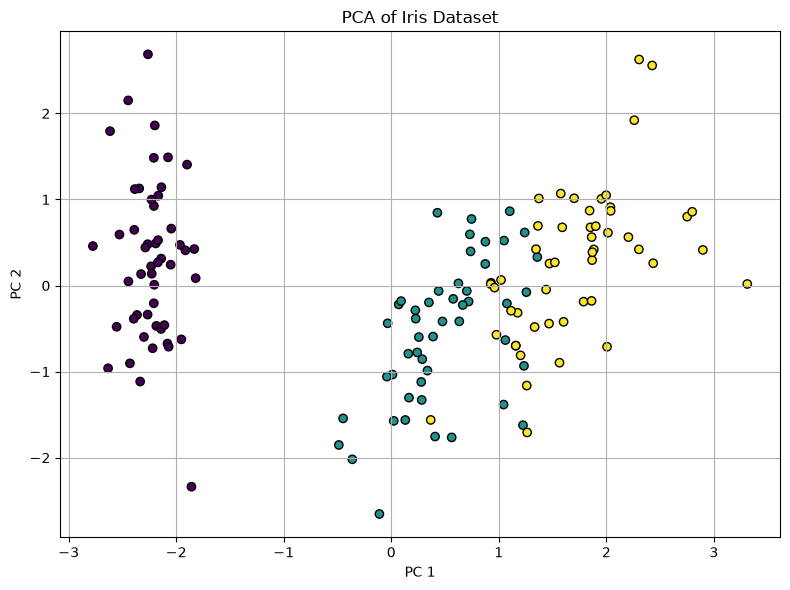

In [30]:
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(X)

fig = plt.figure(1, figsize=(8, 6)) 
plt.clf() 

plt.scatter(pca_features[:,0], pca_features[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title("PCA of Iris Dataset")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(True)

plt.tight_layout()
# plt.savefig('scatter-.png', dpi=150)
plt.show() 

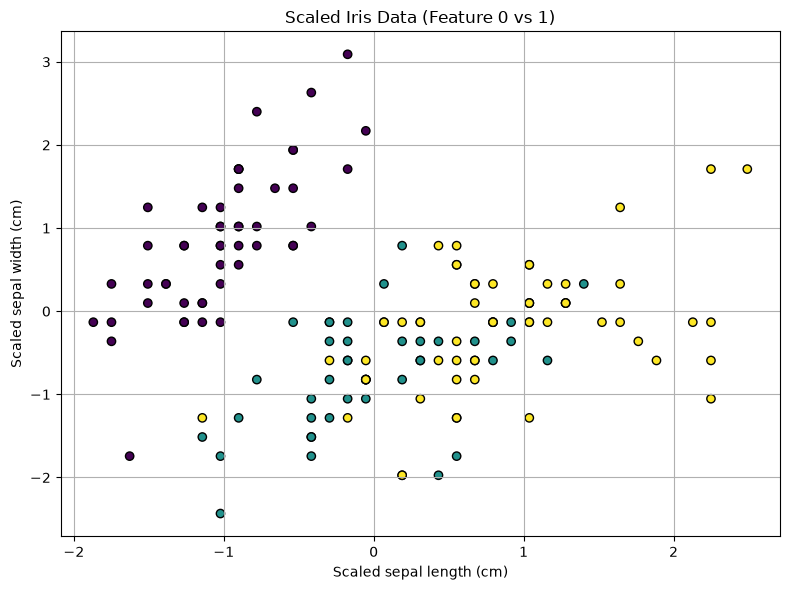

In [13]:
fig = plt.figure(1, figsize=(8, 6)) 
plt.clf() 

plt.scatter(X[:,0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title("Scaled Iris Data (Feature 0 vs 1)")
plt.xlabel(f"Scaled {iris.feature_names[0]}")
plt.ylabel(f"Scaled {iris.feature_names[1]}")
plt.grid(True)

plt.tight_layout()
# plt.savefig('scatter-original.png', dpi=150)
plt.show() 

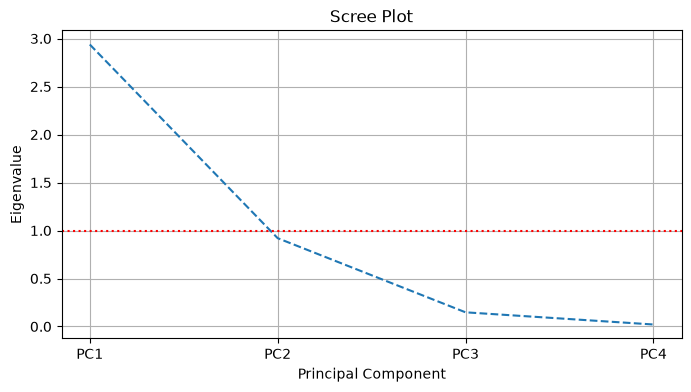

In [36]:
pca2 = PCA().fit(X)

eig = pca2.explained_variance_
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(eig) + 1), eig, linestyle="--"
)
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")

plt.xticks(ticks=[1, 2, 3, 4], labels=['PC1', 'PC2', 'PC3', 'PC4'])

plt.axhline(y=1, color="r", linestyle=":")
plt.grid(True)
plt.savefig('scree-plot.png', dpi=150)
plt.show()

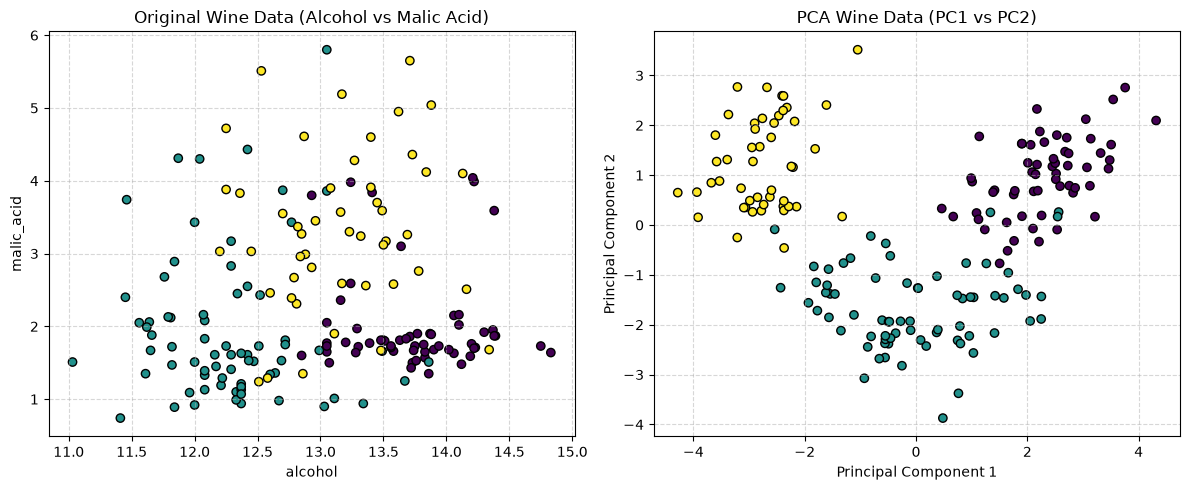

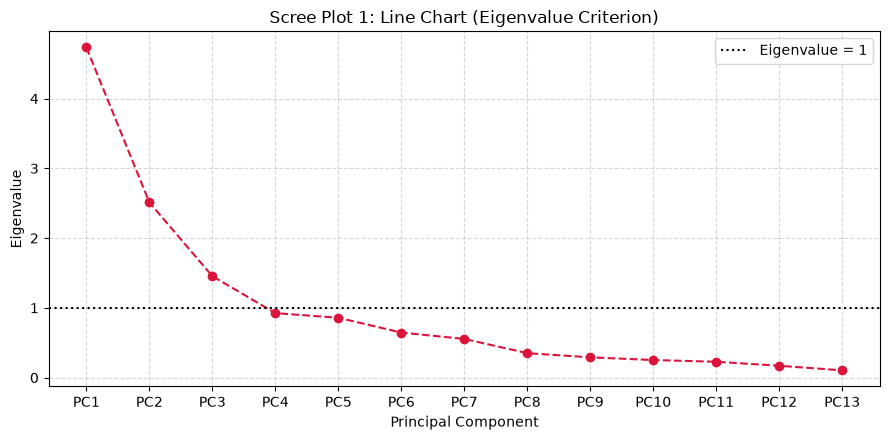

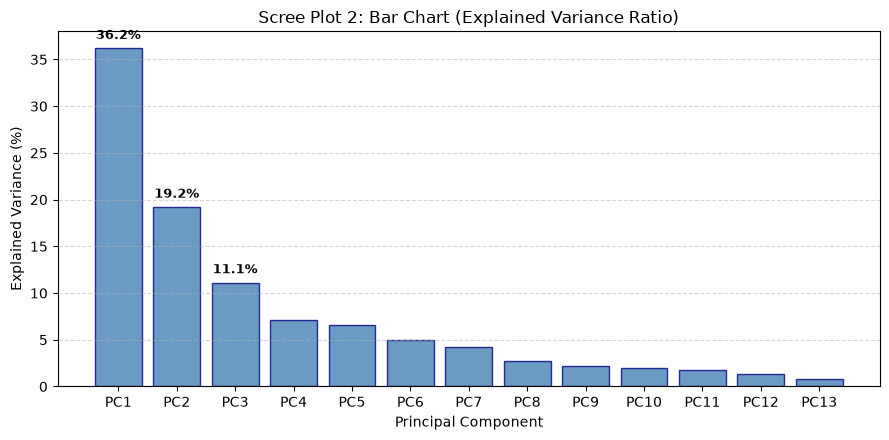

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

wine = load_wine()
x = wine.data
y = wine.target

# ปรับสเกลข้อมูล (Standardization)
scaler = StandardScaler()
X = scaler.fit_transform(x)

# ทำ PCA ลดเหลือ 2 มิติ
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X)

plt.figure(figsize=(12, 5))

# --- กราฟที่ 1: Original Data (ใช้ฟีเจอร์ Alcohol vs Malic Acid) ---
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title("Original Wine Data (Alcohol vs Malic Acid)")
plt.xlabel(wine.feature_names[0])
plt.ylabel(wine.feature_names[1])
plt.grid(True, linestyle='--', alpha=0.5)

# --- กราฟที่ 2: PCA Data (PC1 vs PC2) ---
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title("PCA Wine Data (PC1 vs PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('wine_original_vs_pca.png', dpi=150)
plt.show()

# ==========================================
# 3. Scree Plot อีก 2 แบบ (กราฟเส้น & กราฟแท่ง)
# ==========================================
# รัน PCA สำหรับทุกฟีเจอร์ (13 Components)
pca_full = PCA().fit(X)
eig = pca_full.explained_variance_               # ค่า Eigenvalue
var_ratio = pca_full.explained_variance_ratio_ * 100  # ค่า Variance Ratio (%)
num_pc = len(eig)
pc_labels = [f'PC{i+1}' for i in range(num_pc)]

# --- Scree Plot แบบที่ 1: กราฟเส้น (Eigenvalue Criterion) ---
plt.figure(figsize=(9, 4.5))
plt.plot(range(1, num_pc + 1), eig, marker='o', linestyle='--', color='crimson')
plt.axhline(y=1, color='black', linestyle=':', label='Eigenvalue = 1')

plt.title("Scree Plot 1: Line Chart (Eigenvalue Criterion)")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.xticks(ticks=range(1, num_pc + 1), labels=pc_labels)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig('wine_scree_plot_line.png', dpi=150)
plt.show()

# --- Scree Plot แบบที่ 2: กราฟแท่ง (Explained Variance Ratio) ---
plt.figure(figsize=(9, 4.5))
bars = plt.bar(range(1, num_pc + 1), var_ratio, color='steelblue', edgecolor='navy', alpha=0.8)

plt.title("Scree Plot 2: Bar Chart (Explained Variance Ratio)")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.xticks(ticks=range(1, num_pc + 1), labels=pc_labels)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# แสดง % บนแท่งกราฟ 3 แท่งแรก
for i in range(3):
    plt.text(i + 1, var_ratio[i] + 1, f'{var_ratio[i]:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('wine_scree_plot_bar.png', dpi=150)
plt.show()

In [53]:
from sklearn.cluster import AgglomerativeClustering, KMeans
import pandas as pd

In [56]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

model = AgglomerativeClustering(n_clusters=3)
cluster_labels = model.fit_predict(X)

df = pd.DataFrame(X, columns=iris.feature_names)

df['target'] = y

In [52]:
df['cluster_result'] = cluster_labels
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster_result
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
5,5.4,3.9,1.7,0.4,0,1
6,4.6,3.4,1.4,0.3,0,1
7,5.0,3.4,1.5,0.2,0,1
8,4.4,2.9,1.4,0.2,0,1
9,4.9,3.1,1.5,0.1,0,1


In [63]:
kmeans_model = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans_model.fit_predict(X)


results = pd.DataFrame({
    'Hierarchical (Agglomerative)': cluster_labels,
    'k-Mean (Lab06)': kmeans_labels,
    'Target': y
})


pd.set_option('display.max_rows', None)      
pd.set_option('display.max_columns', None)   

results

,Hierarchical (Agglomerative),k-Mean (Lab06),Target
0,1,1,0
1,1,1,0
2,1,1,0
3,1,1,0
4,1,1,0
5,1,1,0
6,1,1,0
7,1,1,0
8,1,1,0
9,1,1,0


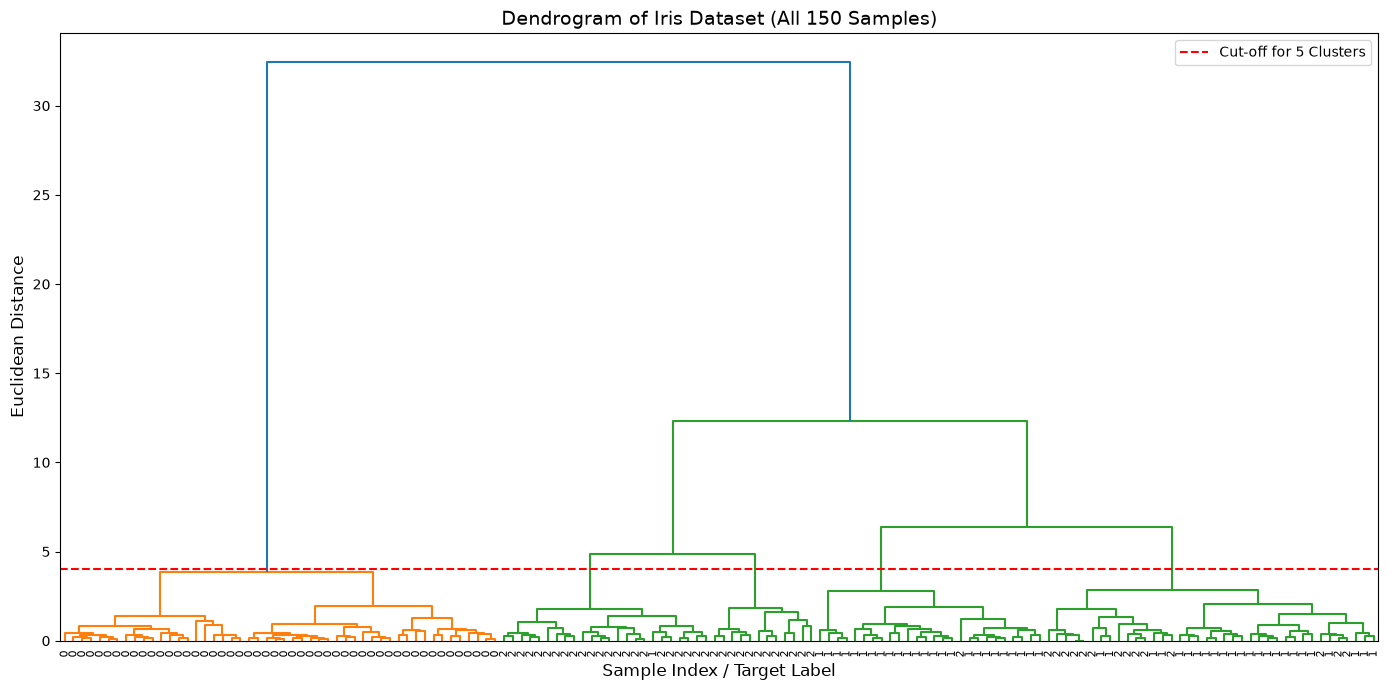

In [72]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage

iris = load_iris()
X = iris.data

Z = linkage(X, method='ward')


plt.figure(figsize=(14, 7))
dendrogram(
    Z,
    labels=iris.target,      
    leaf_rotation=90.,       
    leaf_font_size=8.        
)

plt.title('Dendrogram of Iris Dataset (All 150 Samples)', fontsize=14)
plt.xlabel('Sample Index / Target Label', fontsize=12)
plt.ylabel('Euclidean Distance', fontsize=12)

plt.axhline(y=4, color='r', linestyle='--', label='Cut-off for 5 Clusters')
plt.legend()

plt.tight_layout()
plt.show()